# 농작물(벼) 질병 분류 — Google Colab

Paddy Doctor 멀티태스크 모델(질병 / 품종 / 생육 일수)을 Colab GPU에서 학습합니다.

**사용 순서**
1. 런타임 → 런타임 유형 변경 → **T4 GPU** 선택
2. 데이터 zip을 업로드하거나 Google Drive 경로를 지정
3. 위에서부터 셀을 순서대로 실행
4. 마지막 셀에서 이미지를 올리면 질병을 예측합니다

**zip 안에 있어야 하는 구조**
```
paddy-disease-classification.zip
 ├─ train.csv
 ├─ sample_submission.csv   (없어도 됨)
 ├─ train_images/
 │   └─ {질병라벨}/xxx.jpg
 └─ test_images/            (없어도 됨)
```


## 1. 패키지 설치 및 GPU 확인


In [1]:
%pip install -q timm

import os
import glob
import shutil
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from PIL import Image

try:
    from google.colab import files, drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False
    files = None
    drive = None

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"Colab: {IN_COLAB}")

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    if hasattr(torch, "set_float32_matmul_precision"):
        torch.set_float32_matmul_precision("high")
    props = torch.cuda.get_device_properties(0)
    print(f"GPU: {props.name}")
    print(f"VRAM: {props.total_memory / 1024**3:.1f} GB")
else:
    print("GPU가 없습니다. Colab 메뉴에서 런타임 → 런타임 유형 변경 → T4 GPU를 선택하세요.")


Using device: cuda
Colab: True
GPU: NVIDIA A100-SXM4-40GB
VRAM: 39.5 GB


## 2. 데이터 zip 준비 및 압축 해제

아래 중 하나를 사용합니다.

- **Drive**: zip을 Google Drive에 올려 둔 뒤 `ZIP_PATH`에 경로를 넣습니다.
- **직접 업로드**: `ZIP_PATH`를 비워 두면 파일 선택창이 열립니다. (파일이 크면 Drive가 더 빠릅니다)


In [2]:
# True로 바꾸면 Google Drive를 마운트합니다.
MOUNT_DRIVE = False

# Drive에 zip이 있으면 여기에 경로를 넣으세요. 예: /content/drive/MyDrive/paddy-disease-classification.zip
ZIP_PATH = ""

# 압축을 풀 위치
EXTRACT_DIR = "/content/paddy-data" if IN_COLAB else "./paddy-data"

if MOUNT_DRIVE:
    if not IN_COLAB:
        raise RuntimeError("Google Drive 마운트는 Colab에서만 사용할 수 있습니다.")
    drive.mount("/content/drive")
    print("Drive mounted: /content/drive")


In [3]:
def find_zip_file(explicit_path=""):
    if explicit_path and os.path.isfile(explicit_path):
        return explicit_path

    search_roots = ["."]
    if IN_COLAB:
        search_roots = ["/content", "/content/drive/MyDrive"]

    hits = []
    keywords = ("paddy", "disease", "rice", "농작", "벼")
    for root in search_roots:
        if not os.path.isdir(root):
            continue
        for path in glob.glob(os.path.join(root, "**", "*.zip"), recursive=True):
            name = os.path.basename(path).lower()
            if any(k in name for k in keywords):
                hits.append(path)
        for path in glob.glob(os.path.join(root, "*.zip")):
            if path not in hits:
                hits.append(path)

    if hits:
        hits = sorted(set(hits), key=lambda p: (0 if "paddy" in os.path.basename(p).lower() else 1, len(p)))
        print("찾은 zip 파일:")
        for p in hits[:10]:
            print(" -", p)
        return hits[0]
    return None


zip_path = find_zip_file(ZIP_PATH)

if zip_path is None:
    if not IN_COLAB:
        raise FileNotFoundError(
            "zip 파일을 찾지 못했습니다. ZIP_PATH에 로컬 zip 경로를 넣거나, "
            "Colab에서 이 셀을 실행해 업로드하세요."
        )
    print("zip 파일이 없습니다. 업로드 창에서 paddy-disease-classification.zip 을 선택하세요.")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("zip이 업로드되지 않았습니다.")
    zip_name = next(iter(uploaded))
    zip_path = os.path.join("/content", zip_name)
    print(f"업로드 완료: {zip_path}")

print(f"사용할 zip: {zip_path}")
print(f"파일 크기: {os.path.getsize(zip_path) / 1024**2:.1f} MB")


찾은 zip 파일:
 - /content/paddy-disease-classification.zip
사용할 zip: /content/paddy-disease-classification.zip
파일 크기: 1042.7 MB


In [4]:
def unzip_dataset(zip_path, extract_dir):
    os.makedirs(extract_dir, exist_ok=True)
    print(f"압축 해제 중 → {extract_dir}")
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("압축 해제 완료")


def find_dataset_root(extract_dir):
    # zip 안에 폴더가 한 겹 더 있는 경우를 포함해 train.csv 위치를 찾습니다.
    for root, _, filenames in os.walk(extract_dir):
        if "train.csv" in filenames:
            train_img = os.path.join(root, "train_images")
            if os.path.isdir(train_img):
                return root
            return root
    raise FileNotFoundError(
        f"{extract_dir} 아래에서 train.csv를 찾지 못했습니다. zip 구조를 확인하세요."
    )


unzip_dataset(zip_path, EXTRACT_DIR)
BASE_DIR = find_dataset_root(EXTRACT_DIR)
print(f"데이터 루트: {BASE_DIR}")
print("구성:", sorted(os.listdir(BASE_DIR))[:20])


압축 해제 중 → /content/paddy-data
압축 해제 완료
데이터 루트: /content/paddy-data
구성: ['sample_submission.csv', 'test_images', 'train.csv', 'train_images']


## 3. 데이터 확인 및 탐색


In [5]:
TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
df = pd.read_csv(TRAIN_CSV)

print(f"data size: {len(df)}")
print(df.head())
print(df.info())
print("\n질병 클래스:")
print(df["label"].value_counts())


data size: 10407
     image_id                  label variety  age
0  100330.jpg  bacterial_leaf_blight   ADT45   45
1  100365.jpg  bacterial_leaf_blight   ADT45   45
2  100382.jpg  bacterial_leaf_blight   ADT45   45
3  100632.jpg  bacterial_leaf_blight   ADT45   45
4  101918.jpg  bacterial_leaf_blight   ADT45   45
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10407 entries, 0 to 10406
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   image_id  10407 non-null  object
 1   label     10407 non-null  object
 2   variety   10407 non-null  object
 3   age       10407 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 325.3+ KB
None

질병 클래스:
label
normal                      1764
blast                       1738
hispa                       1594
dead_heart                  1442
tungro                      1088
brown_spot                   965
downy_mildew                 620
bacterial_leaf_blight        479
bacterial_l

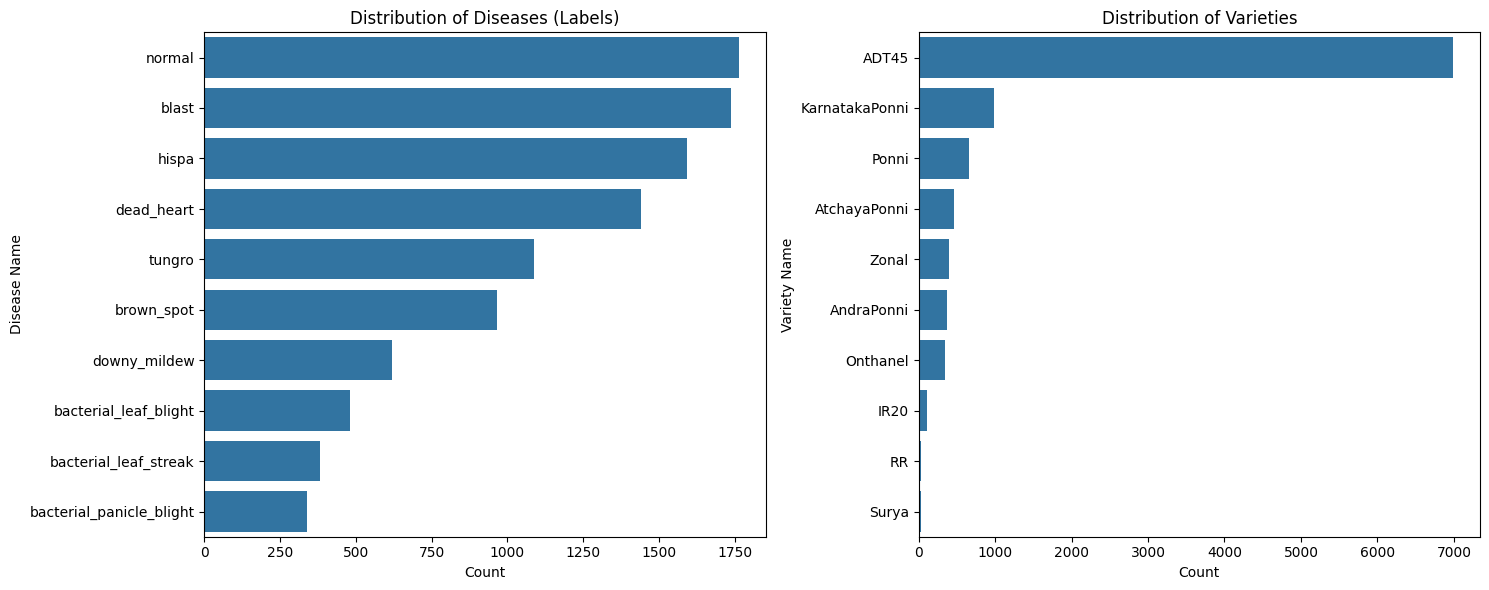

In [6]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1)
sns.countplot(y="label", data=df, order=df["label"].value_counts().index)
plt.title("Distribution of Diseases (Labels)")
plt.xlabel("Count")
plt.ylabel("Disease Name")

plt.subplot(1, 2, 2)
sns.countplot(y="variety", data=df, order=df["variety"].value_counts().index)
plt.title("Distribution of Varieties")
plt.xlabel("Count")
plt.ylabel("Variety Name")

plt.tight_layout()
plt.show()


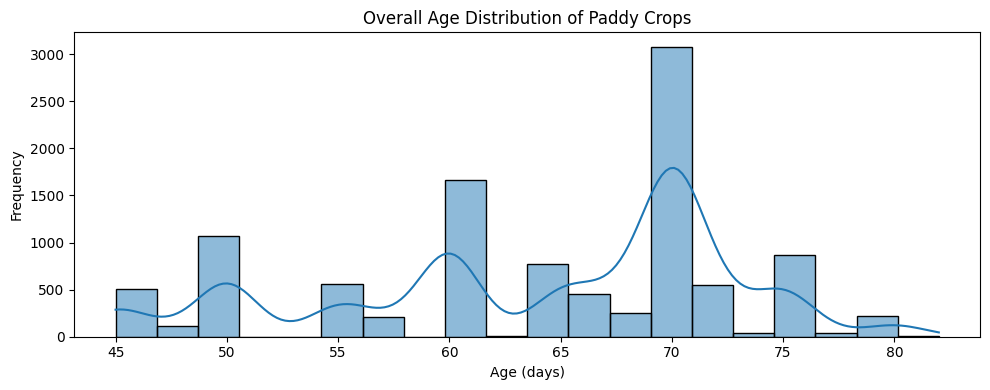

In [7]:
plt.figure(figsize=(10, 4))
sns.histplot(df["age"], kde=True, bins=20)
plt.title("Overall Age Distribution of Paddy Crops")
plt.xlabel("Age (days)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


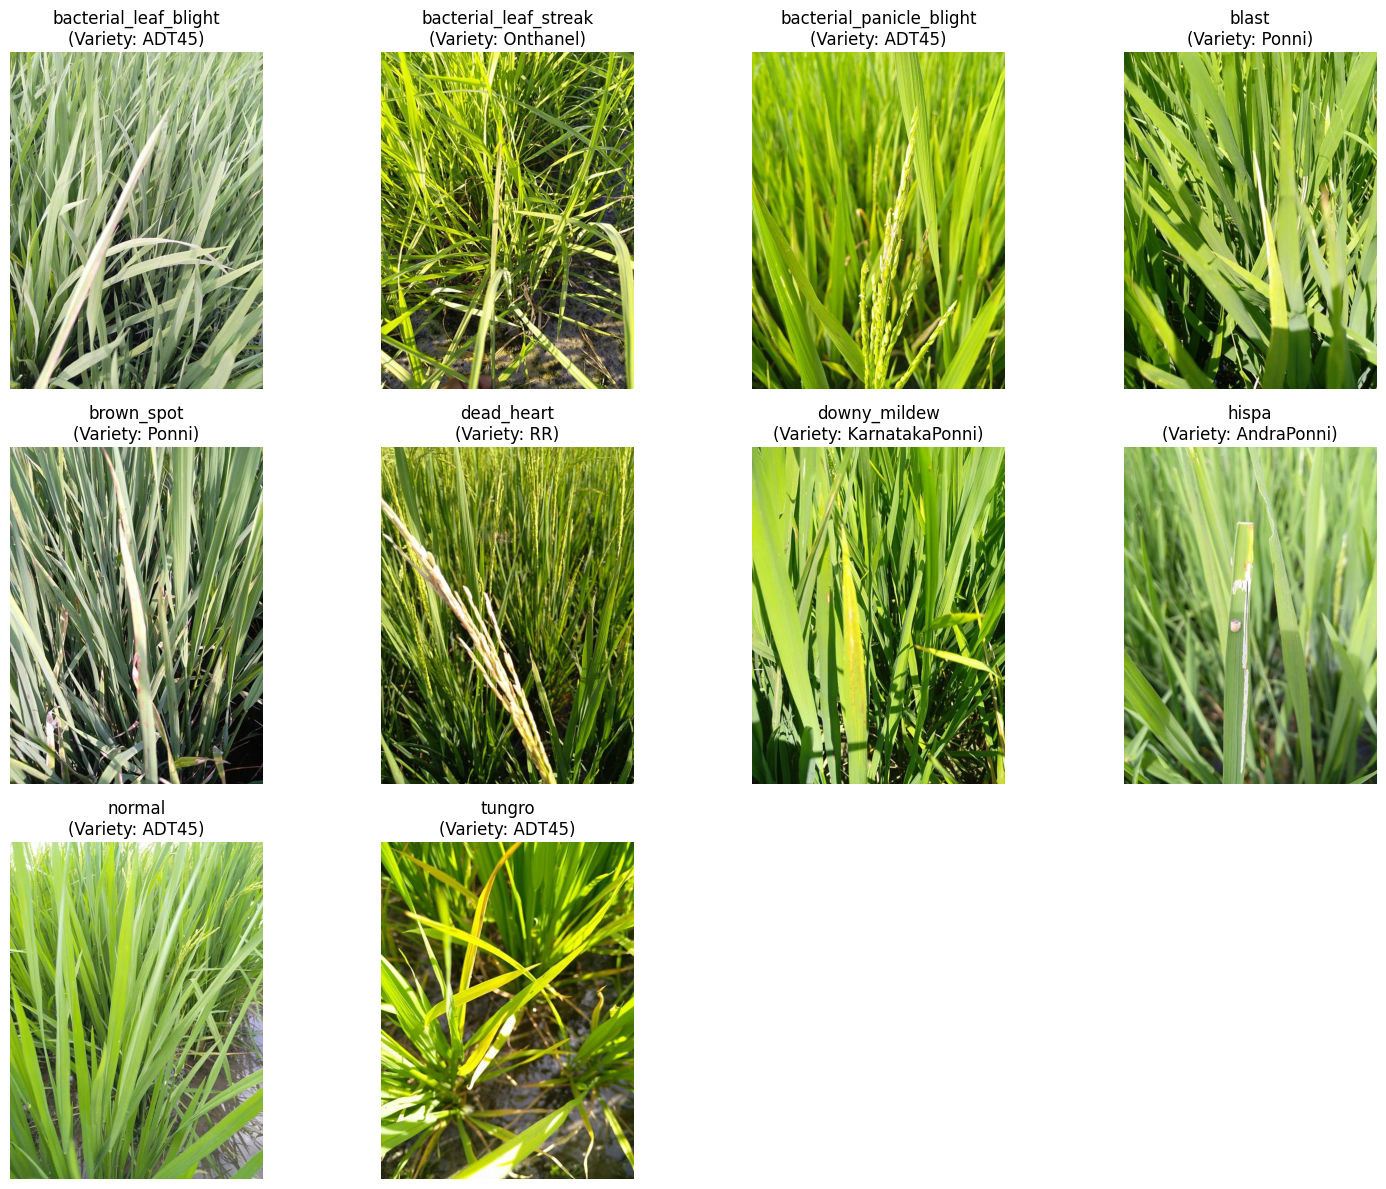

In [8]:
def get_image_path(row):
    return os.path.join(BASE_DIR, "train_images", row["label"], row["image_id"])

df["path"] = df.apply(get_image_path, axis=1)

unique_labels = df["label"].unique()
plt.figure(figsize=(15, 12))

for i, label in enumerate(unique_labels):
    sample_row = df[df["label"] == label].sample(1, random_state=0).iloc[0]
    img = Image.open(sample_row["path"])
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(f"{label}\n(Variety: {sample_row['variety']})")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. 전처리


In [9]:
from sklearn.model_selection import train_test_split

INPUT_DIR = BASE_DIR
train_df = pd.read_csv(os.path.join(INPUT_DIR, "train.csv"))

sample_csv = os.path.join(INPUT_DIR, "sample_submission.csv")
if os.path.isfile(sample_csv):
    sample_sub = pd.read_csv(sample_csv)
    sample_sub["path"] = sample_sub["image_id"].apply(
        lambda x: os.path.join(INPUT_DIR, "test_images", x)
    )
else:
    sample_sub = None
    print("sample_submission.csv가 없어 테스트셋 경로는 건너뜁니다.")

train_df["path"] = train_df.apply(
    lambda x: os.path.join(INPUT_DIR, "train_images", x["label"], x["image_id"]),
    axis=1,
)

labels = sorted(train_df["label"].unique())
label2id = {label: i for i, label in enumerate(labels)}
id2label = {i: label for i, label in enumerate(labels)}
train_df["label_id"] = train_df["label"].map(label2id)

varieties = sorted(train_df["variety"].unique())
variety2id = {v: i for i, v in enumerate(varieties)}
id2variety = {i: v for i, v in enumerate(varieties)}
train_df["variety_id"] = train_df["variety"].map(variety2id)

num_diseases = len(labels)
num_varieties = len(varieties)
print(f"Number of diseases: {num_diseases}")
print(f"Number of varieties: {num_varieties}")
print("질병 클래스:", labels)

train_data, valid_data = train_test_split(
    train_df,
    test_size=0.2,
    stratify=train_df["label"],
    random_state=42,
)

print(f"Train data: {len(train_data)}, Valid data: {len(valid_data)}")


Number of diseases: 10
Number of varieties: 10
질병 클래스: ['bacterial_leaf_blight', 'bacterial_leaf_streak', 'bacterial_panicle_blight', 'blast', 'brown_spot', 'dead_heart', 'downy_mildew', 'hispa', 'normal', 'tungro']
Train data: 8325, Valid data: 2082


## 5. Dataset / DataLoader


In [10]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms.functional import resize as tv_resize

try:
    from torchvision.io import read_image, ImageReadMode
    _HAS_TV_IO = True
except Exception:
    _HAS_TV_IO = False


class FastImageTransform:
    def __init__(self, size, mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)):
        self.size = size
        self.mean = torch.tensor(mean, dtype=torch.float32).view(3, 1, 1)
        self.std = torch.tensor(std, dtype=torch.float32).view(3, 1, 1)

    def __call__(self, img):
        img = img.float().div(255.0)
        img = tv_resize(img, [self.size, self.size], antialias=True)
        return (img - self.mean) / self.std


class PaddyDataset(Dataset):
    def __init__(self, df, transform=None, is_test=False):
        self.paths = df["path"].tolist()
        self.transform = transform
        self.is_test = is_test
        if not is_test:
            self.targets = df["label_id"].to_numpy(np.int64, copy=False)
            self.varieties = df["variety_id"].to_numpy(np.int64, copy=False)
            self.ages = df["age"].to_numpy(np.float32, copy=False)

    def __len__(self):
        return len(self.paths)

    def _load_image(self, path):
        if _HAS_TV_IO:
            try:
                return read_image(path, mode=ImageReadMode.RGB)
            except Exception:
                pass
        pil_img = Image.open(path).convert("RGB")
        return torch.from_numpy(np.array(pil_img, copy=True)).permute(2, 0, 1).contiguous()

    def __getitem__(self, idx):
        image = self._load_image(self.paths[idx])
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            return image
        return (
            image,
            int(self.targets[idx]),
            int(self.varieties[idx]),
            float(self.ages[idx]),
        )


IMAGE_SIZE = 224
train_transform = FastImageTransform(IMAGE_SIZE)
val_transform = FastImageTransform(IMAGE_SIZE)

train_ds = PaddyDataset(train_data, transform=train_transform)
valid_ds = PaddyDataset(valid_data, transform=val_transform)


def auto_batch_size():
    if not torch.cuda.is_available():
        return 32
    mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    if mem_gb >= 20:
        return 256
    if mem_gb >= 12:
        return 192
    if mem_gb >= 8:
        return 128
    if mem_gb >= 6:
        return 96
    if mem_gb >= 4:
        return 64
    return 32


BATCH_SIZE = auto_batch_size()
# Colab(Linux)에서는 워커 2개가 안정적입니다.
NUM_WORKERS = 2 if IN_COLAB else 0
USE_CUDA = torch.cuda.is_available()


def make_loader(dataset, shuffle=False, drop_last=False):
    kwargs = dict(
        dataset=dataset,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=USE_CUDA,
        drop_last=drop_last,
    )
    if NUM_WORKERS > 0:
        kwargs["persistent_workers"] = True
        kwargs["prefetch_factor"] = 2
    return DataLoader(**kwargs)


train_loader = make_loader(train_ds, shuffle=True, drop_last=True)
valid_loader = make_loader(valid_ds, shuffle=False, drop_last=False)
print(f"DataLoaders are ready. batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS}")


DataLoaders are ready. batch_size=256, num_workers=2


## 6. 모델 정의


In [11]:
import timm
import torch.nn as nn
import torch.optim as optim


class PaddyMultiTaskModel(nn.Module):
    def __init__(self, model_name="resnet18", pretrained=True, num_diseases=10, num_varieties=10):
        super().__init__()
        self.backbone = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        n_features = self.backbone.num_features
        self.fc_disease = nn.Linear(n_features, num_diseases)
        self.fc_variety = nn.Linear(n_features, num_varieties)
        self.fc_age = nn.Linear(n_features, 1)

    def forward(self, x):
        features = self.backbone(x)
        out_d = self.fc_disease(features)
        out_v = self.fc_variety(features)
        out_a = self.fc_age(features)
        return out_d, out_v, out_a


print("Model class is ready")


Model class is ready


## 7. 학습


In [12]:
from torch.amp import GradScaler, autocast
from tqdm.notebook import tqdm

model = PaddyMultiTaskModel(
    model_name="resnet18",
    pretrained=True,
    num_diseases=num_diseases,
    num_varieties=num_varieties,
)

use_cuda = device.type == "cuda"
if use_cuda:
    model = model.to(device, memory_format=torch.channels_last)
else:
    model = model.to(device)

try:
    optimizer = optim.Adam(model.parameters(), lr=1e-3, fused=use_cuda)
except (TypeError, RuntimeError):
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

criterion_disease = nn.CrossEntropyLoss()
criterion_variety = nn.CrossEntropyLoss()
criterion_age = nn.MSELoss()
scaler = GradScaler("cuda", enabled=use_cuda)

epochs = 5
WEIGHT_V = 0.05
WEIGHT_A = 0.0
best_acc = 0.0
save_path = "best_model.pth"

print(f"Start Training for {epochs} epochs... (AMP={use_cuda}, batch_size={BATCH_SIZE})")

for epoch in range(epochs):
    model.train()
    train_loss = torch.zeros((), device=device)
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]")

    for step, (images, targets, varieties_b, ages) in enumerate(pbar, 1):
        if use_cuda:
            images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
        else:
            images = images.to(device)
        targets = targets.to(device, non_blocking=use_cuda)
        varieties_b = varieties_b.to(device, non_blocking=use_cuda)
        ages = ages.to(device, non_blocking=use_cuda).float()

        optimizer.zero_grad(set_to_none=True)

        with autocast("cuda", enabled=use_cuda):
            out_disease, out_variety, out_age = model(images)
            loss_d = criterion_disease(out_disease, targets)
            loss_v = criterion_variety(out_variety, varieties_b)
            loss_a = criterion_age(out_age.view(-1), ages)
            loss = loss_d + (WEIGHT_V * loss_v) + (WEIGHT_A * loss_a)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_loss += loss.detach().float()
        if step % 20 == 0:
            pbar.set_postfix({"loss": float(loss.detach())})

    avg_train_loss = (train_loss / len(train_loader)).item()

    model.eval()
    correct_counts = torch.zeros((), device=device, dtype=torch.long)
    total_counts = 0
    with torch.inference_mode():
        for images, targets, varieties_b, ages in tqdm(
            valid_loader, desc=f"Epoch {epoch+1}/{epochs} [Valid]", leave=False
        ):
            if use_cuda:
                images = images.to(device, non_blocking=True, memory_format=torch.channels_last)
            else:
                images = images.to(device)
            targets = targets.to(device, non_blocking=use_cuda)
            with autocast("cuda", enabled=use_cuda):
                out_disease, _, _ = model(images)
            predicted = out_disease.argmax(1)
            total_counts += targets.size(0)
            correct_counts += (predicted == targets).sum()

    val_acc = correct_counts.item() / total_counts
    print(f"Epoch {epoch+1} Result:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Valid Acc : {val_acc:.4f} ({val_acc*100:.2f}%)")

    if val_acc > best_acc:
        print(f"  [Create Best Model] Accuracy improved from {best_acc:.4f} to {val_acc:.4f}. Saving model...")
        best_acc = val_acc
        torch.save(
            {
                "model": model.state_dict(),
                "id2label": id2label,
                "id2variety": id2variety,
                "num_diseases": num_diseases,
                "num_varieties": num_varieties,
                "image_size": IMAGE_SIZE,
            },
            save_path,
        )
    else:
        print(f"  Accuracy did not improve from {best_acc:.4f}.")
    print("-" * 30)

print("Training Finished.")
print(f"Best Validation Accuracy: {best_acc:.4f}")

# Colab A100 약 3분 소요


model.safetensors: reconstructing file:   0%|          |  0.00B / 46.8MB            

model.safetensors: downloading bytes:           |  0.00B            

Start Training for 5 epochs... (AMP=True, batch_size=256)


Epoch 1/5 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 1/5 [Valid]:   0%|          | 0/9 [00:00<?, ?it/s]

...

Epoch 4/5 [Valid]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 4 Result:
  Train Loss: 0.0736
  Valid Acc : 0.9318 (93.18%)
  [Create Best Model] Accuracy improved from 0.9164 to 0.9318. Saving model...
------------------------------


Epoch 5/5 [Train]:   0%|          | 0/32 [00:00<?, ?it/s]

Epoch 5/5 [Valid]:   0%|          | 0/9 [00:00<?, ?it/s]

Epoch 5 Result:
  Train Loss: 0.0372
  Valid Acc : 0.9428 (94.28%)
  [Create Best Model] Accuracy improved from 0.9318 to 0.9428. Saving model...
------------------------------
Training Finished.
Best Validation Accuracy: 0.9428


## 8. 이미지 업로드 후 예측

학습이 끝난 뒤 이 셀을 실행하면 파일 선택창이 열립니다.  
벼 잎 사진(jpg/png)을 올리면 질병, 품종, 생육 일수 예측 결과를 보여 줍니다.


모델 로드 완료. 예측할 이미지를 업로드하세요. (jpg/png, 여러 장 가능)


Saving 100023.jpg to 100023 (1).jpg


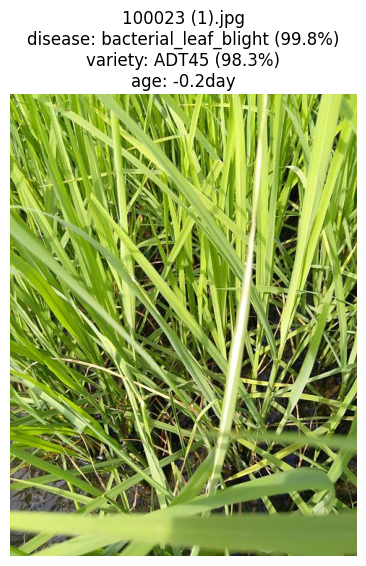

파일: 100023 (1).jpg
질병 Top-3
  - bacterial_leaf_blight           99.8%
  - tungro                           0.1%
  - brown_spot                       0.0%
품종 Top-3
  - ADT45                           98.3%
  - Ponni                            1.4%
  - IR20                             0.1%
생육 일수: -0.2일
----------------------------------------


In [14]:
from torch.amp import autocast
from torch.nn.functional import softmax

SAVE_PATH = "best_model.pth"
UPLOAD_DIR = "/content/uploaded_images" if IN_COLAB else "./uploaded_images"
os.makedirs(UPLOAD_DIR, exist_ok=True)


def load_trained_model(ckpt_path):
    try:
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    except TypeError:
        ckpt = torch.load(ckpt_path, map_location=device)

    if isinstance(ckpt, dict) and "model" in ckpt:
        state = ckpt["model"]
        local_id2label = ckpt.get("id2label", id2label)
        local_id2variety = ckpt.get("id2variety", id2variety)
        n_d = ckpt.get("num_diseases", num_diseases)
        n_v = ckpt.get("num_varieties", num_varieties)
    else:
        state = ckpt
        local_id2label, local_id2variety = id2label, id2variety
        n_d, n_v = num_diseases, num_varieties
        if any(k.startswith("module.") for k in state):
            state = {k.replace("module.", "", 1): v for k, v in state.items()}

    pred_model = PaddyMultiTaskModel(
        model_name="resnet18",
        pretrained=False,
        num_diseases=n_d,
        num_varieties=n_v,
    )
    pred_model.load_state_dict(state)
    if device.type == "cuda":
        pred_model = pred_model.to(device, memory_format=torch.channels_last)
    else:
        pred_model = pred_model.to(device)
    pred_model.eval()
    return pred_model, local_id2label, local_id2variety


def pil_to_tensor(pil_img):
    arr = np.array(pil_img.convert("RGB"), copy=True)
    return torch.from_numpy(arr).permute(2, 0, 1).contiguous()


def predict_one(pred_model, image_path, local_id2label, local_id2variety, topk=3):
    pil_img = Image.open(image_path).convert("RGB")
    tensor = val_transform(pil_to_tensor(pil_img)).unsqueeze(0)
    if device.type == "cuda":
        tensor = tensor.to(device, memory_format=torch.channels_last)
    else:
        tensor = tensor.to(device)

    with torch.inference_mode():
        with autocast("cuda", enabled=device.type == "cuda"):
            out_d, out_v, out_a = pred_model(tensor)

    disease_prob = softmax(out_d.float(), dim=1)[0]
    variety_prob = softmax(out_v.float(), dim=1)[0]
    age_pred = float(out_a.float().view(-1)[0].cpu())

    top_d = torch.topk(disease_prob, k=min(topk, disease_prob.numel()))
    top_v = torch.topk(variety_prob, k=min(topk, variety_prob.numel()))

    disease_rank = [
        (local_id2label[int(i)], float(p)) for p, i in zip(top_d.values.cpu(), top_d.indices.cpu())
    ]
    variety_rank = [
        (local_id2variety[int(i)], float(p)) for p, i in zip(top_v.values.cpu(), top_v.indices.cpu())
    ]
    return pil_img, disease_rank, variety_rank, age_pred


if not os.path.isfile(SAVE_PATH):
    raise FileNotFoundError("best_model.pth가 없습니다. 먼저 학습 셀을 실행하세요.")

pred_model, pred_id2label, pred_id2variety = load_trained_model(SAVE_PATH)
print("모델 로드 완료. 예측할 이미지를 업로드하세요. (jpg/png, 여러 장 가능)")

if IN_COLAB:
    uploaded = files.upload()
    image_paths = []
    for name, data in uploaded.items():
        out_path = os.path.join(UPLOAD_DIR, os.path.basename(name))
        with open(out_path, "wb") as f:
            f.write(data)
        image_paths.append(out_path)
else:
    raise RuntimeError("이 셀은 Colab의 파일 업로드용입니다. Colab에서 실행하세요.")

if not image_paths:
    raise FileNotFoundError("업로드된 이미지가 없습니다.")

for path in image_paths:
    pil_img, disease_rank, variety_rank, age_pred = predict_one(
        pred_model, path, pred_id2label, pred_id2variety
    )
    best_disease, best_d_score = disease_rank[0]
    best_variety, best_v_score = variety_rank[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(
        f"{os.path.basename(path)}\n"
        f"disease: {best_disease} ({best_d_score*100:.1f}%)\n"
        f"variety: {best_variety} ({best_v_score*100:.1f}%)\n"
        f"age: {age_pred:.1f}day"
    )
    plt.show()

    print(f"파일: {os.path.basename(path)}")
    print("질병 Top-3")
    for name, score in disease_rank:
        print(f"  - {name:30s} {score*100:5.1f}%")
    print("품종 Top-3")
    for name, score in variety_rank:
        print(f"  - {name:30s} {score*100:5.1f}%")
    print(f"생육 일수: {age_pred:.1f}일")
    print("-" * 40)
